In [151]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [152]:
def Plot_CMB_Map(Map_to_Plot,c_min,c_max,X_width,Y_width):
    print("map mean:",np.mean(Map_to_Plot),"map rms:",np.std(Map_to_Plot))
    plt.gcf().set_size_inches(10, 10)
    im = plt.imshow(Map_to_Plot, interpolation='bilinear', origin='lower',cmap=cm.RdBu_r)
    im.set_clim(c_min,c_max)
    ax=plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    cbar = plt.colorbar(im, cax=cax)
    im.set_extent([0,X_width,0,Y_width])
    plt.ylabel('angle $[^\circ]$')
    plt.xlabel('angle $[^\circ]$')
    cbar.set_label('tempearture [uK]', rotation=270)
    plt.show()

def calc_white_noise(kgrid, loc=0., scale=1.):
    white_noise = np.zeros(kgrid.shape, dtype=np.complex64)
    for i in range(kgrid.shape[0]):
        for j in range(kgrid.shape[1]):
            white_noise[i,j] = (np.random.normal(loc,scale)+1j*np.random.normal(loc,scale))/np.sqrt(2)
    return white_noise
      
def calc_primordial_power(kgrid, cosmo):
    pk = np.zeros_like(kgrid)
    idx = np.where(kgrid > 0)
    pfactor = cosmo['A']*cosmo['kpivot']**(1.-cosmo['ns'])
    pk[idx] = np.power(kgrid[idx], cosmo['ns']-4.)*pfactor
    pk[0,0] = 0
    return pk

def calc_non_gaussian(F_nl, field):
    return 5/3 * F_nl * field**2

def apply_linear_power_or_transfer(delta_c,kgrid,kLin,PLin_or_TFLin):
    # Helperfunction to apply interpolated powerspectrum or transferfunction in parallel
    for i in np.arange(kgrid.shape[0]):
        delta_c[i] *= np.interp(kgrid[i],kLin,PLin_or_TFLin)
    delta_c[0,0] = 0

In [153]:
def cosine_window(N):
    "makes a cosine window for apodizing to avoid edges effects in the 2d FFT" 
    # make a 2d coordinate system
    N=int(N) 
    ones = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.)/N *np.pi ## eg runs from -pi/2 to pi/2
    X = np.outer(ones,inds)
    Y = np.transpose(X)

    # make a window map
    window_map = np.cos(X) * np.cos(Y)

    # return the window map
    return(window_map)

def calculate_2d_spectrum(Map,delta_ell,ell_max):
    "calcualtes the power spectrum of a 2d map by FFTing, squaring, and azimuthally averaging"
    pix_size= 0.5
    
    # make a 2d ell coordinate system
    ones = np.ones(grid)
    inds  = (np.arange(grid)+.5 - grid/2.) /(grid-1.)
    kX = np.outer(ones,inds) / (pix_size/60. * np.pi/180.)
    kY = np.transpose(kX)
    K = np.sqrt(kX**2. + kY**2.)

    ell_scale_factor = 2*np.pi
    ell2d = K * ell_scale_factor

    # make an array to hold the power spectrum results
    N_bins = int(ell_max/delta_ell)
    ell_array = np.arange(N_bins)
    CL_array = np.zeros(N_bins)
    
    # get the 2d fourier transform of the map
    FMap1 = np.fft.ifft2(np.fft.fftshift(Map))
    FMap2 = np.fft.ifft2(np.fft.fftshift(Map))
    PSMap = np.fft.fftshift(np.real(np.conj(FMap1) * FMap2))
    # fill out the spectra
    i = 0
    while (i < N_bins):
        ell_array[i] = (i + 0.5) * delta_ell
        inds_in_bin = ((ell2d >= (i* delta_ell)) * (ell2d < ((i+1)* delta_ell))).nonzero()
        if np.sum(inds_in_bin) == 0:
            CL_array[i] = 0
        else:
            CL_array[i] = np.mean(PSMap[inds_in_bin])
        # print(i, ell_array[i], inds_in_bin, CL_array[i])
        i = i + 1

    # return the power spectrum and ell bins
    return(ell_array, CL_array*np.sqrt(pix_size/60.* np.pi/180.)*2.)

def plot_cls(title=None):               
    window = (cosine_window(grid))
    appodized_map = window * map
    
    ls, cls = calculate_2d_spectrum(appodized_map, 50, 5000)
    dls = ls * (ls + 1) / (2 * np.pi**2) * cls
    
    plt.loglog(ls, dls)
    plt.legend()
    plt.show()

In [154]:
cosmo = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'A': 2*np.pi*np.pi*2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 5000,
    'accuracy_boost': 4,
}
h = cosmo['h']

grid = 128

box_size = 1000. #Size of periodic box e.g. in Mpc/h
cell_size = box_size / grid #Physical size of grid-cell
kF = 2*np.pi / box_size #Fundamental frequency
kNyq = kF * grid / 2 #Nyquist frequency of the grid

#Setup mesh and k-space grid
kx = 2 * np.pi * np.fft.fftfreq( grid, cell_size)
ky = 2 * np.pi * np.fft.rfftfreq(grid, cell_size)
kmesh = np.meshgrid(kx,ky,indexing="ij")
k_hgrid = np.sqrt(kmesh[0]**2 + kmesh[1]**2)
kgrid = k_hgrid * h

In [155]:
density_field = calc_white_noise(k_hgrid)
density_field *=  np.sqrt( calc_primordial_power(kgrid, cosmo) ) * grid**2/(box_size/h)**1.5
density_field[k_hgrid > kNyq] = 0.+0.j

real_field = np.fft.irfft2(density_field)
real_field += calc_non_gaussian(1, real_field)
density_field = np.fft.rfft2(real_field)

kLin, TFLin = np.loadtxt("data/linear_thomas/LinearTransfer.dat")[:,[0,1]].T
apply_linear_power_or_transfer(density_field, k_hgrid, kLin, TFLin)

map = np.fft.irfft2(density_field)

map mean: 2.168404344971009e-19 map rms: 0.1621241412875731


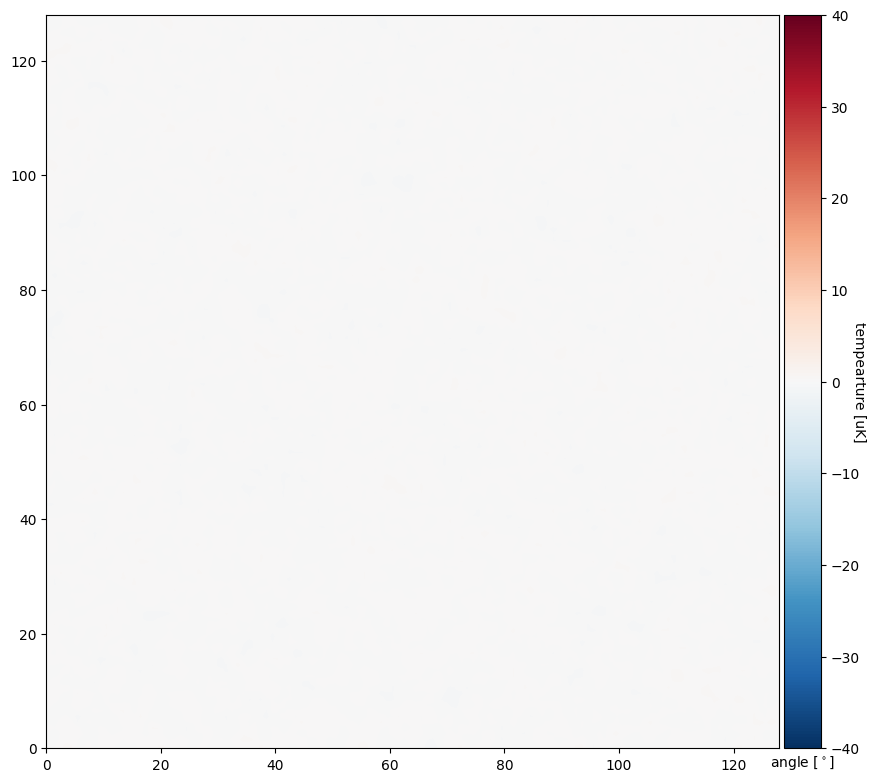

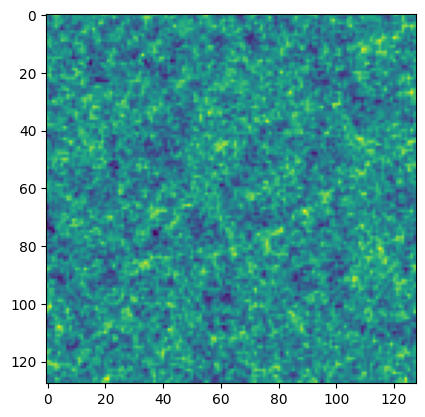

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


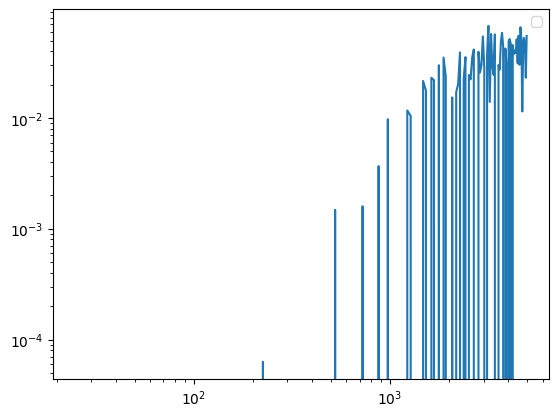

In [156]:
width = grid
Plot_CMB_Map(map, -40, 40, width, width)

plt.imshow(map)
plt.show()

plot_cls()